# Task 2: Exploratory Data Analysis (EDA)

## Forecasting Financial Inclusion in Ethiopia

### Week 11 Challenge

**Student:** Lalise Fufi

---

## Objective

The objective of this notebook is to explore Ethiopia's financial inclusion dataset, identify historical trends, understand relationships among indicators, investigate the influence of major events, assess data quality, and generate insights that will guide the forecasting models developed in later tasks.

1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

2. Load the Enriched Dataset

In [3]:
DATA = Path("../data/processed")

df = pd.read_csv(DATA / "ethiopia_fi_enriched.csv")

impact_links = pd.read_csv(
    DATA / "impact_links_enriched.csv"
)

reference = pd.read_csv(
    "../data/raw/reference_codes.csv"
)

In [4]:
print(df.shape)

print(impact_links.shape)

print(reference.shape)

(46, 34)
(15, 35)
(71, 4)


3. Dataset Overview

In [6]:
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31 00:00:00,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31 00:00:00,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            46 non-null     str    
 1   record_type          46 non-null     str    
 2   category             11 non-null     str    
 3   pillar               35 non-null     str    
 4   indicator            45 non-null     str    
 5   indicator_code       45 non-null     str    
 6   indicator_direction  35 non-null     str    
 7   value_numeric        35 non-null     float64
 8   value_text           11 non-null     str    
 9   value_type           46 non-null     str    
 10  unit                 35 non-null     str    
 11  observation_date     46 non-null     str    
 12  period_start         12 non-null     str    
 13  period_end           12 non-null     str    
 14  fiscal_year          46 non-null     str    
 15  gender               46 non-null     str    
 16  loc

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,46,46,REC_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record_type,46,3,observation,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,11,7,policy,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pillar,35,4,ACCESS,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator,45,31,Account Ownership Rate,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_code,45,31,ACC_OWNERSHIP,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_direction,35,3,higher_better,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_numeric,35.0,NaN,NaN,NaN,88979858305.886566,411074453447.597595,1.08,21.0,56.0,13500000.0,2380000000000.0
value_text,11,4,Launched,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_type,46,8,percentage,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN


4. Dataset Summary

In [9]:
print("Shape:", df.shape)

print()

print(df["record_type"].value_counts())

print()

print(df["pillar"].value_counts(dropna=False))

print()

print(df["source_type"].value_counts(dropna=False))

Shape: (46, 34)

record_type
observation    32
event          11
target          3
Name: count, dtype: int64

pillar
ACCESS           17
USAGE            12
NaN              11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

source_type
operator      16
survey        10
regulator      8
research       4
policy         4
calculated     2
news           2
Name: count, dtype: int64


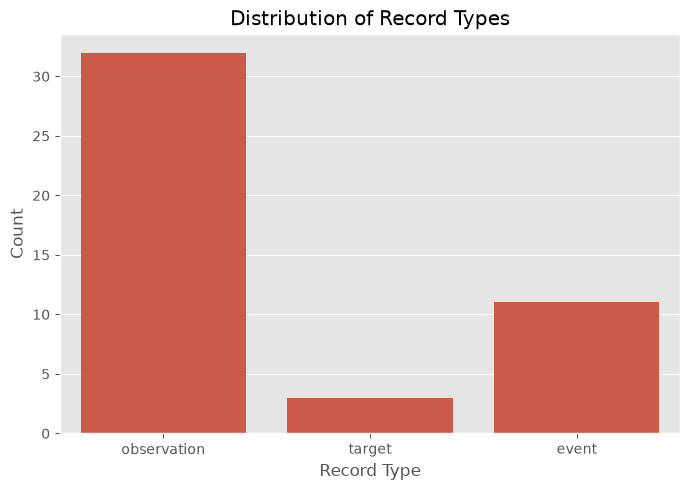

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="record_type"
)

plt.title("Distribution of Record Types")

plt.xlabel("Record Type")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

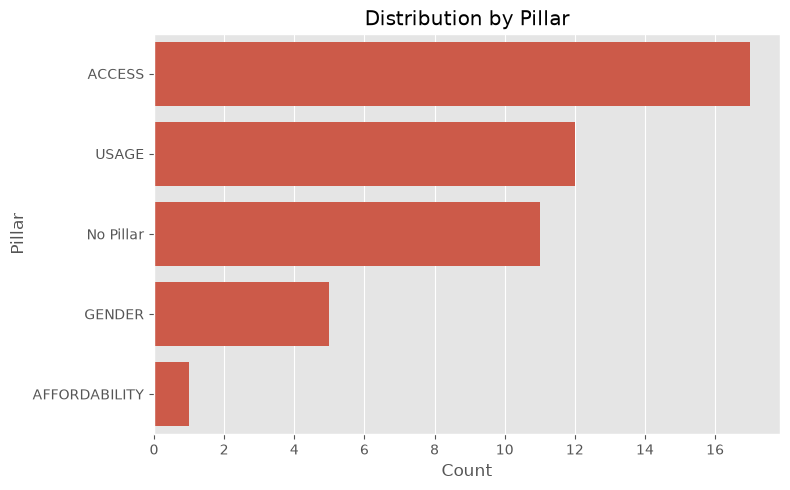

In [12]:
plt.figure(figsize=(8,5))

pillar_plot = df.copy()

pillar_plot["pillar"] = pillar_plot["pillar"].fillna("No Pillar")

sns.countplot(
    data=pillar_plot,
    y="pillar",
    order=pillar_plot["pillar"].value_counts().index
)

plt.title("Distribution by Pillar")

plt.xlabel("Count")

plt.ylabel("Pillar")

plt.tight_layout()

plt.show()

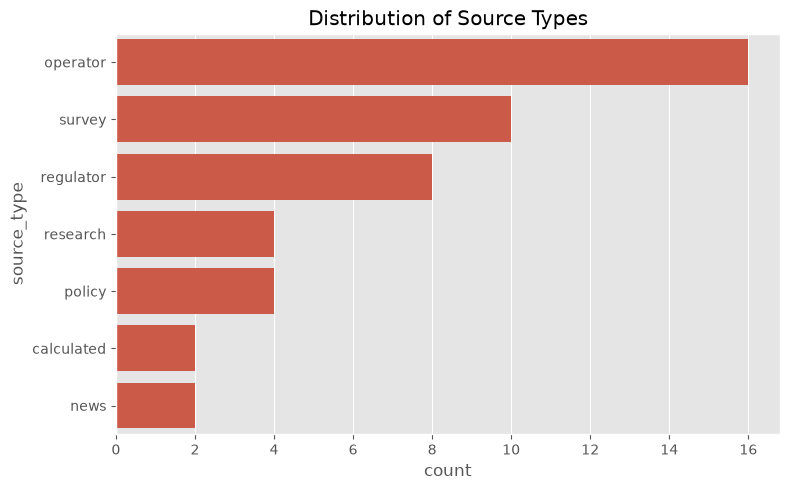

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="source_type",
    order=df["source_type"].value_counts().index
)

plt.title("Distribution of Source Types")

plt.tight_layout()

plt.show()

### Interpretation

The enriched financial inclusion dataset contains **46 records** and **34 variables**, indicating that additional observations and events have been successfully incorporated while preserving the original unified schema. The dataset is dominated by **observation records (32)**, which provide the historical measurements used for trend analysis and forecasting. It also includes **11 event records** representing major policy changes, product launches, market developments, and infrastructure initiatives, together with **3 target records** that capture official financial inclusion goals.

The distribution across financial inclusion pillars shows that **ACCESS (17 records)** and **USAGE (12 records)** receive the greatest coverage, reflecting the primary forecasting objectives of this project. **GENDER (5 records)** and **AFFORDABILITY (1 record)** contain comparatively fewer observations, suggesting that demographic and affordability analyses are more limited. Additionally, **11 records have no assigned pillar**, corresponding to event records. This is expected because, according to the unified data schema, events are intentionally categorized by type (e.g., policy, product launch, infrastructure) rather than by financial inclusion pillar. Their effects on specific indicators are modeled separately through the **impact_link** table.

The source distribution indicates that the dataset relies primarily on **operator reports (16 records)** and **survey data (10 records)**, providing strong empirical evidence from organizations such as Ethio Telecom, Telebirr, M-Pesa, and the World Bank Global Findex. Regulatory publications contribute **8 records**, while **research studies (4)** and **policy documents (4)** provide supporting evidence. A smaller number of records originate from **calculated metrics (2)** and **news sources (2)**. This combination of official, operational, and research-based sources improves the reliability of the dataset while incorporating recent developments in Ethiopia's digital financial ecosystem.

Overall, the enriched dataset provides a balanced representation of financial inclusion indicators, supporting events, and multiple data sources. The additional observations strengthen the coverage of key Access and Usage indicators while maintaining consistency with the project's unified schema, making the dataset suitable for subsequent exploratory analysis, event impact modeling, and forecasting.